#T10(а).


In [1]:
from scipy.stats import chi2, kstwobign, norm
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi, log, sqrt
from mpmath import mp

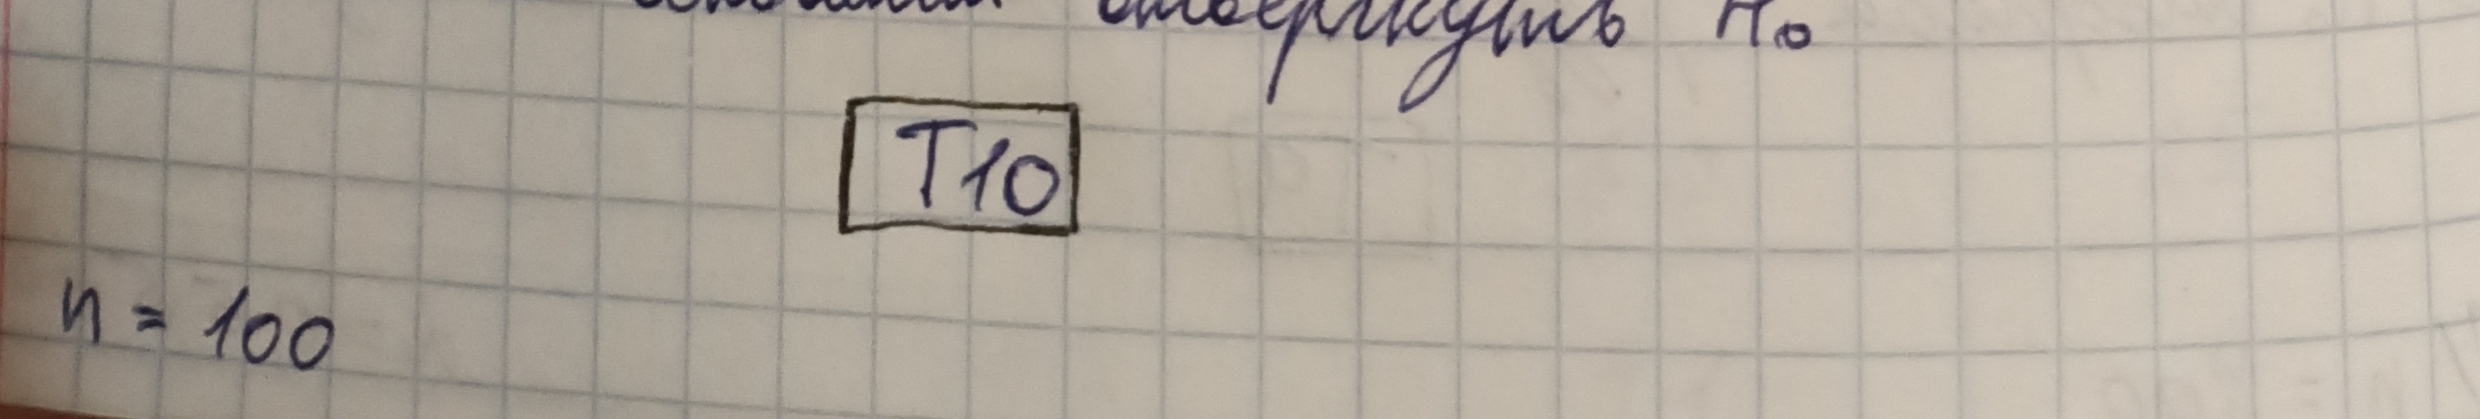

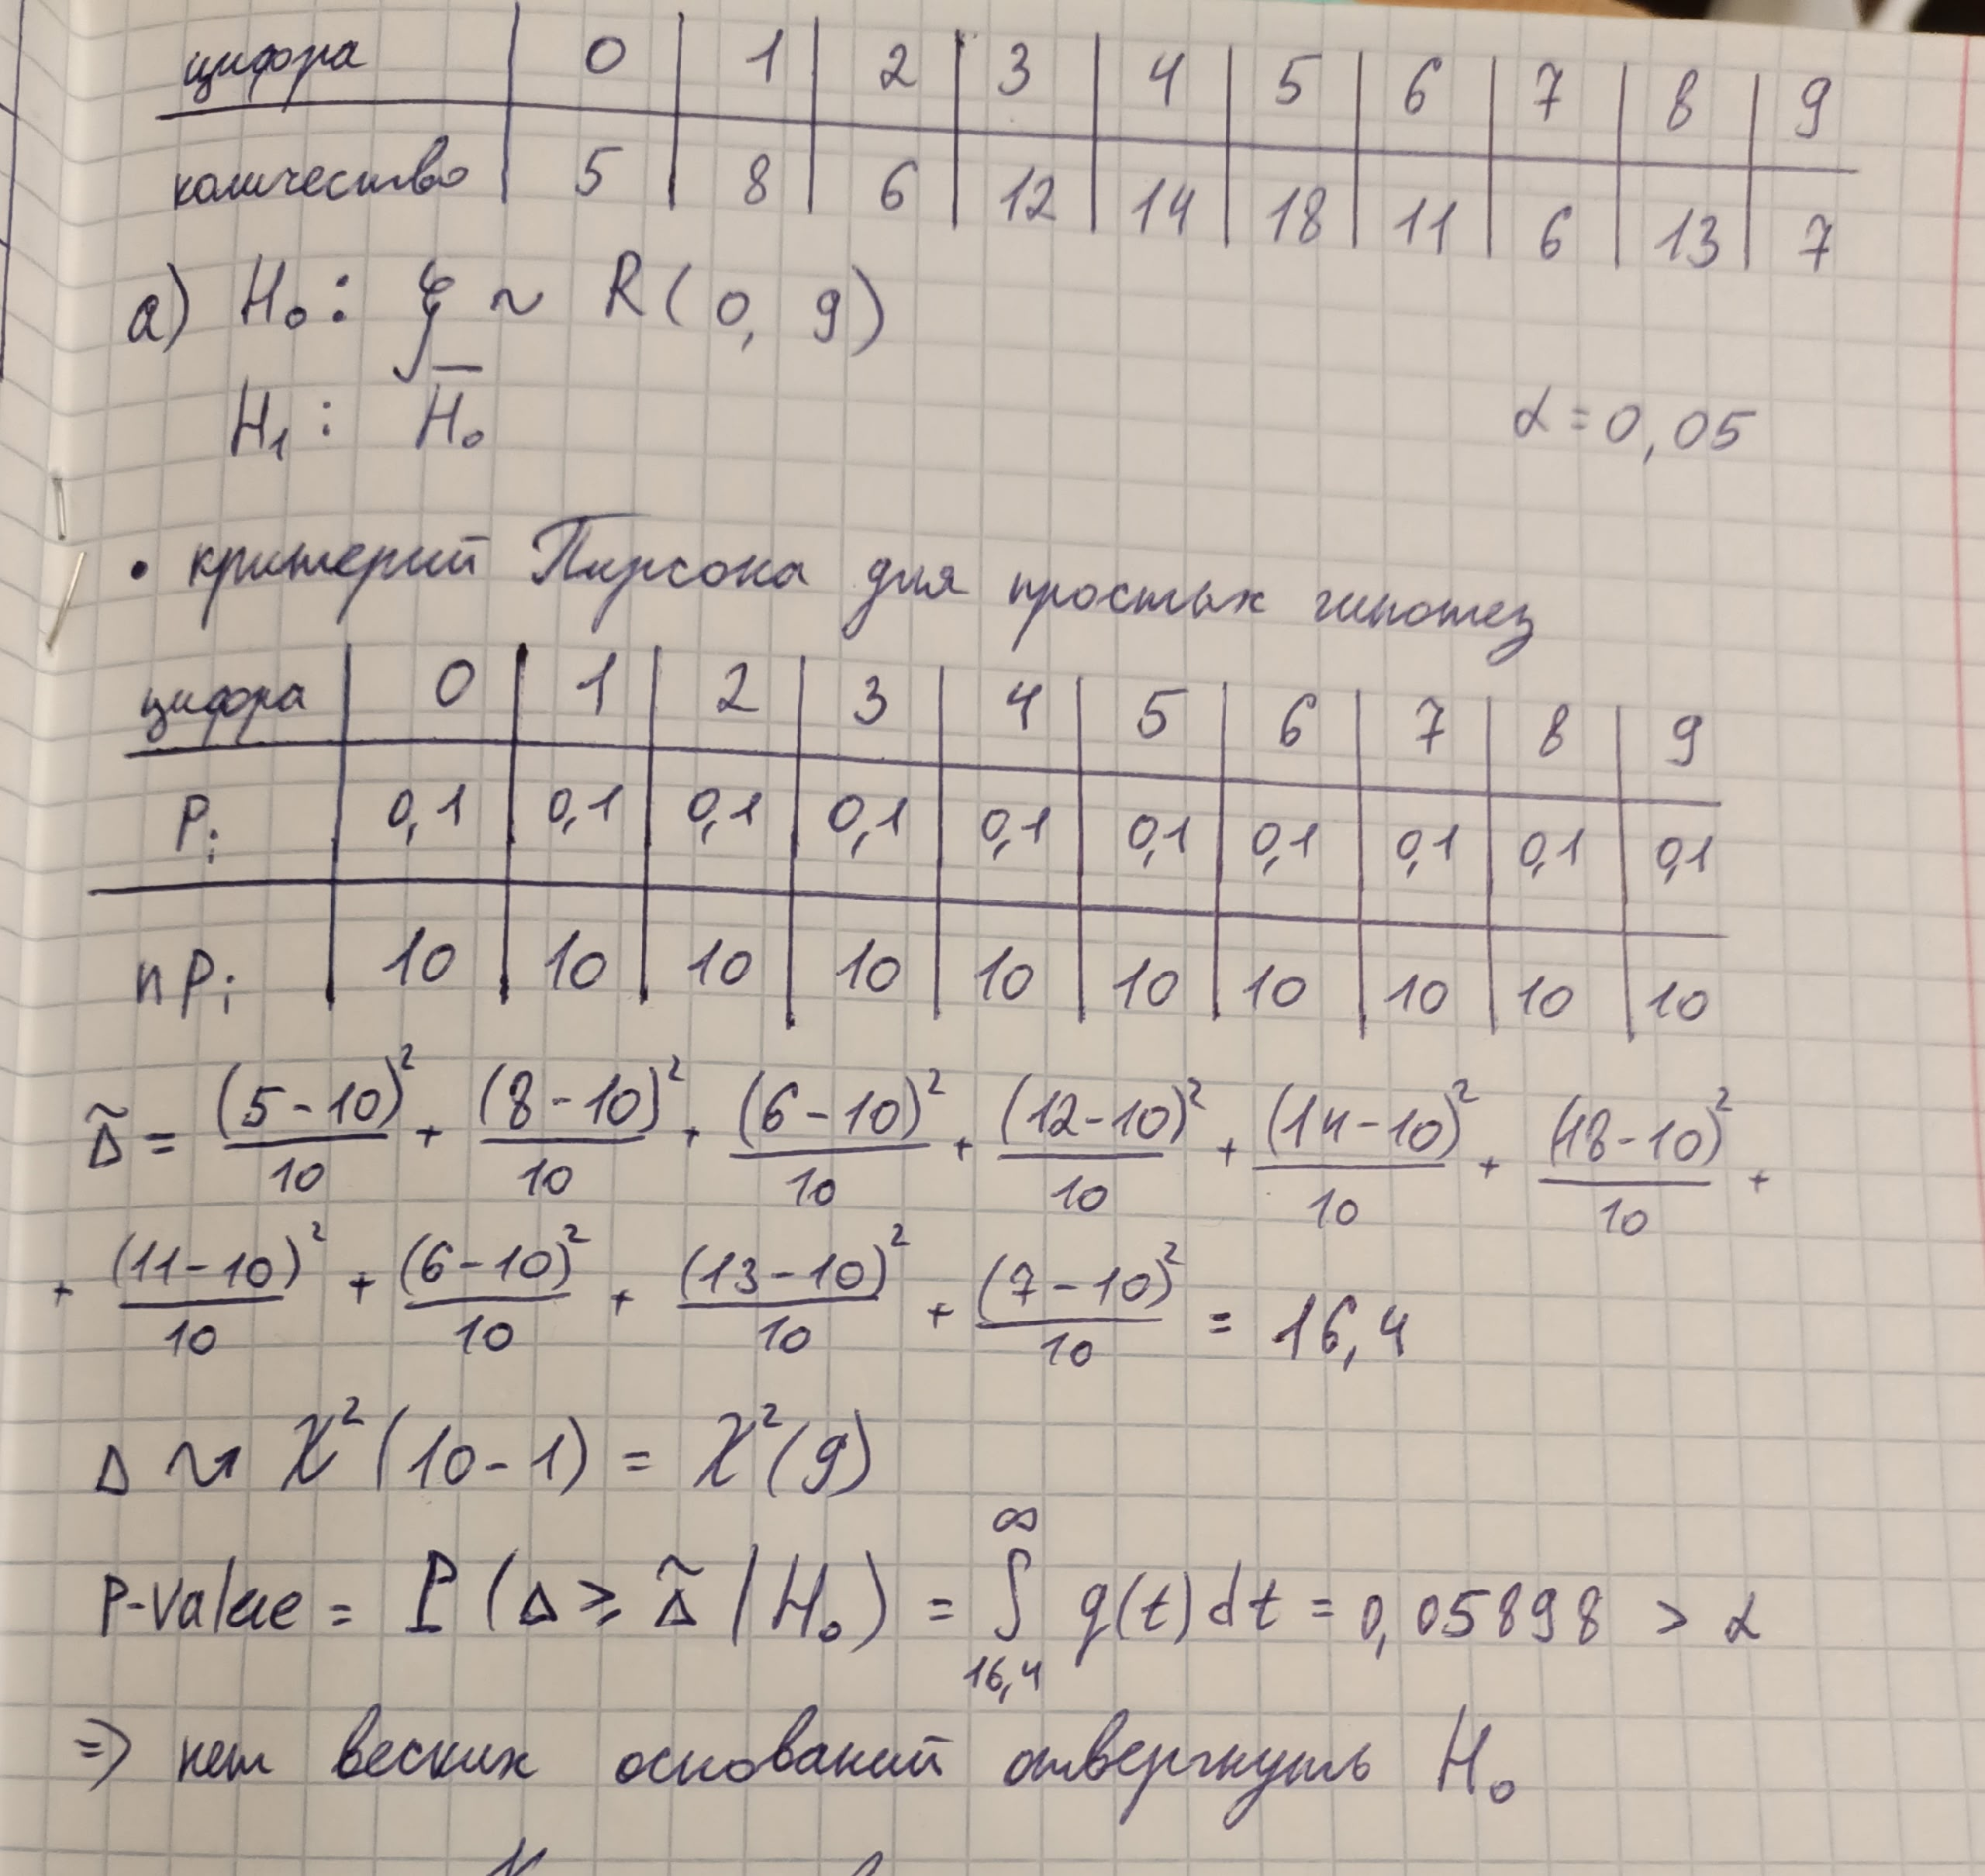

In [2]:
delta = 16.4
p_value = chi2.sf(delta, 9)
print(f"p-value = {p_value}")

p-value = 0.058984030544419454


###Критерий Колмагорова для простых гипотез

In [3]:
n = 100
columns = [i for i in range(0, 9+1)]
index = ["Count"]
data = pd.DataFrame(columns=columns, index = pd.Index(index))
count = np.array([5, 8, 6, 12, 14, 18, 11, 6, 13, 7])
data.loc["Count"] = count
print(data)

       0  1  2   3   4   5   6  7   8  9
Count  5  8  6  12  14  18  11  6  13  7


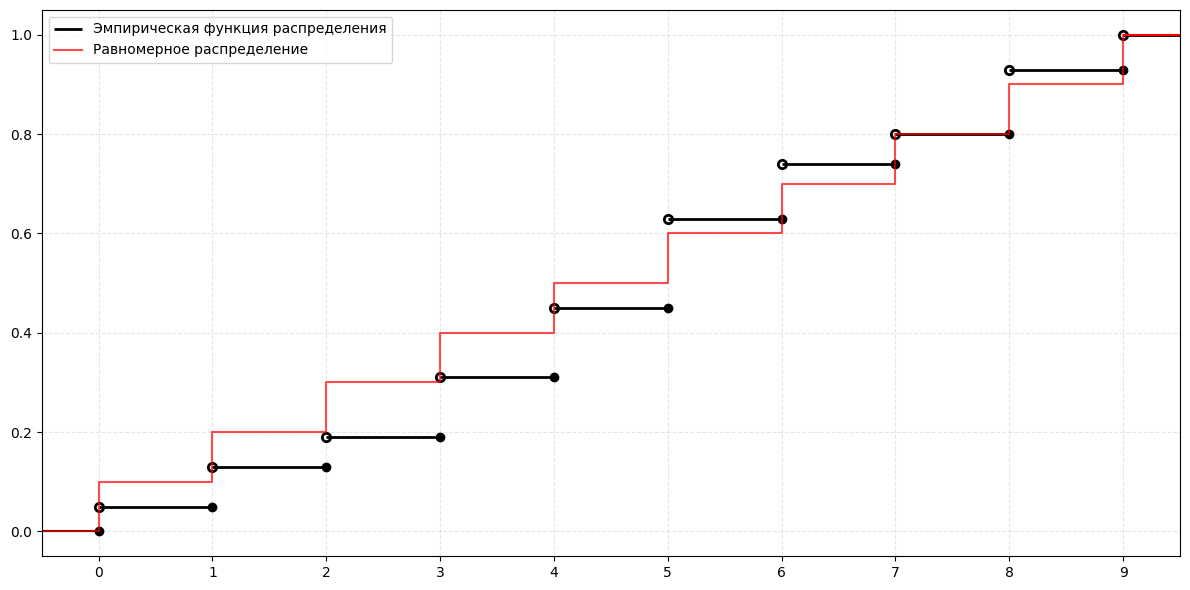

In [4]:
def draw_empirical_function_with_steps(sample_counts: list, n: int, x_range=(0, 9), x_padding=0.5):
    x_points = np.arange(0, 10, 1)
    cumulative_counts = np.cumsum(sample_counts)
    p_empirical = cumulative_counts / n
    fig, ax = plt.subplots(figsize=(12, 6))

    x_min = x_range[0] - x_padding
    x_max = x_range[1] + x_padding

    ax.hlines(y=0, xmin=x_min, xmax=x_points[0], color='black', linewidth=1.5)

    current_height = 0

    for i in range(len(x_points)):
        new_height = p_empirical[i]
        ax.plot(x_points[i], current_height, 'o', color='black', markersize=6,
                markeredgecolor='black', markerfacecolor='black')

        if i == 0:
            ax.hlines(y=current_height, xmin=x_points[0], xmax=x_points[0], color='black', linewidth=2)
        else:
            ax.hlines(y=current_height, xmin=x_points[i-1], xmax=x_points[i], color='black', linewidth=2)

        ax.plot(x_points[i], new_height, 'o', color='black', markersize=6,
                markeredgecolor='black', markerfacecolor='white', markeredgewidth=2)

        current_height = new_height

    ax.hlines(y=1, xmin=x_points[-1], xmax=x_max, color='black', linewidth=2, label='Эмпирическая функция распределения')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(np.arange(x_range[0], x_range[1] + 1, 1))

    return fig, ax, p_empirical


fig, ax, p_emp_up = draw_empirical_function_with_steps(count, n)

x_uniform = np.arange(-1, 10, 1)
p_even = [(i + 1)/10 for i in range(-1, 10)]

ax.hlines(y=1, xmin=9, xmax=10, color='red', linewidth=1.5)
ax.step(x_uniform, p_even, where='post', color='red', linewidth=1.5,
        label='Равномерное распределение', alpha=0.7)

ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [5]:
columns = [i for i in range(0, 9+1)]
index = ["Count", "Pr_emp", "Pr_even"]
data1 = pd.DataFrame(columns=columns, index = pd.Index(index))
data1.loc["Count"] = count
data1.loc["Pr_emp"] = p_emp_up
data1.loc["Pr_even"] = p_even[1:]
print(data1)

            0     1     2     3     4     5     6    7     8    9
Count       5     8     6    12    14    18    11    6    13    7
Pr_emp   0.05  0.13  0.19  0.31  0.45  0.63  0.74  0.8  0.93  1.0
Pr_even   0.1   0.2   0.3   0.4   0.5   0.6   0.7  0.8   0.9  1.0


In [6]:
p_emp_low = np.roll(p_emp_up, 1)
p_emp_low[0] = 0.0
delta1 = np.abs(p_even[1:] - p_emp_low)
delta2 = np.abs(p_even[1:] - p_emp_up)
wave_delta = sqrt(n) * np.max(np.maximum(delta1, delta2))
print("Оценка Δ =", wave_delta)

Оценка Δ = 2.1


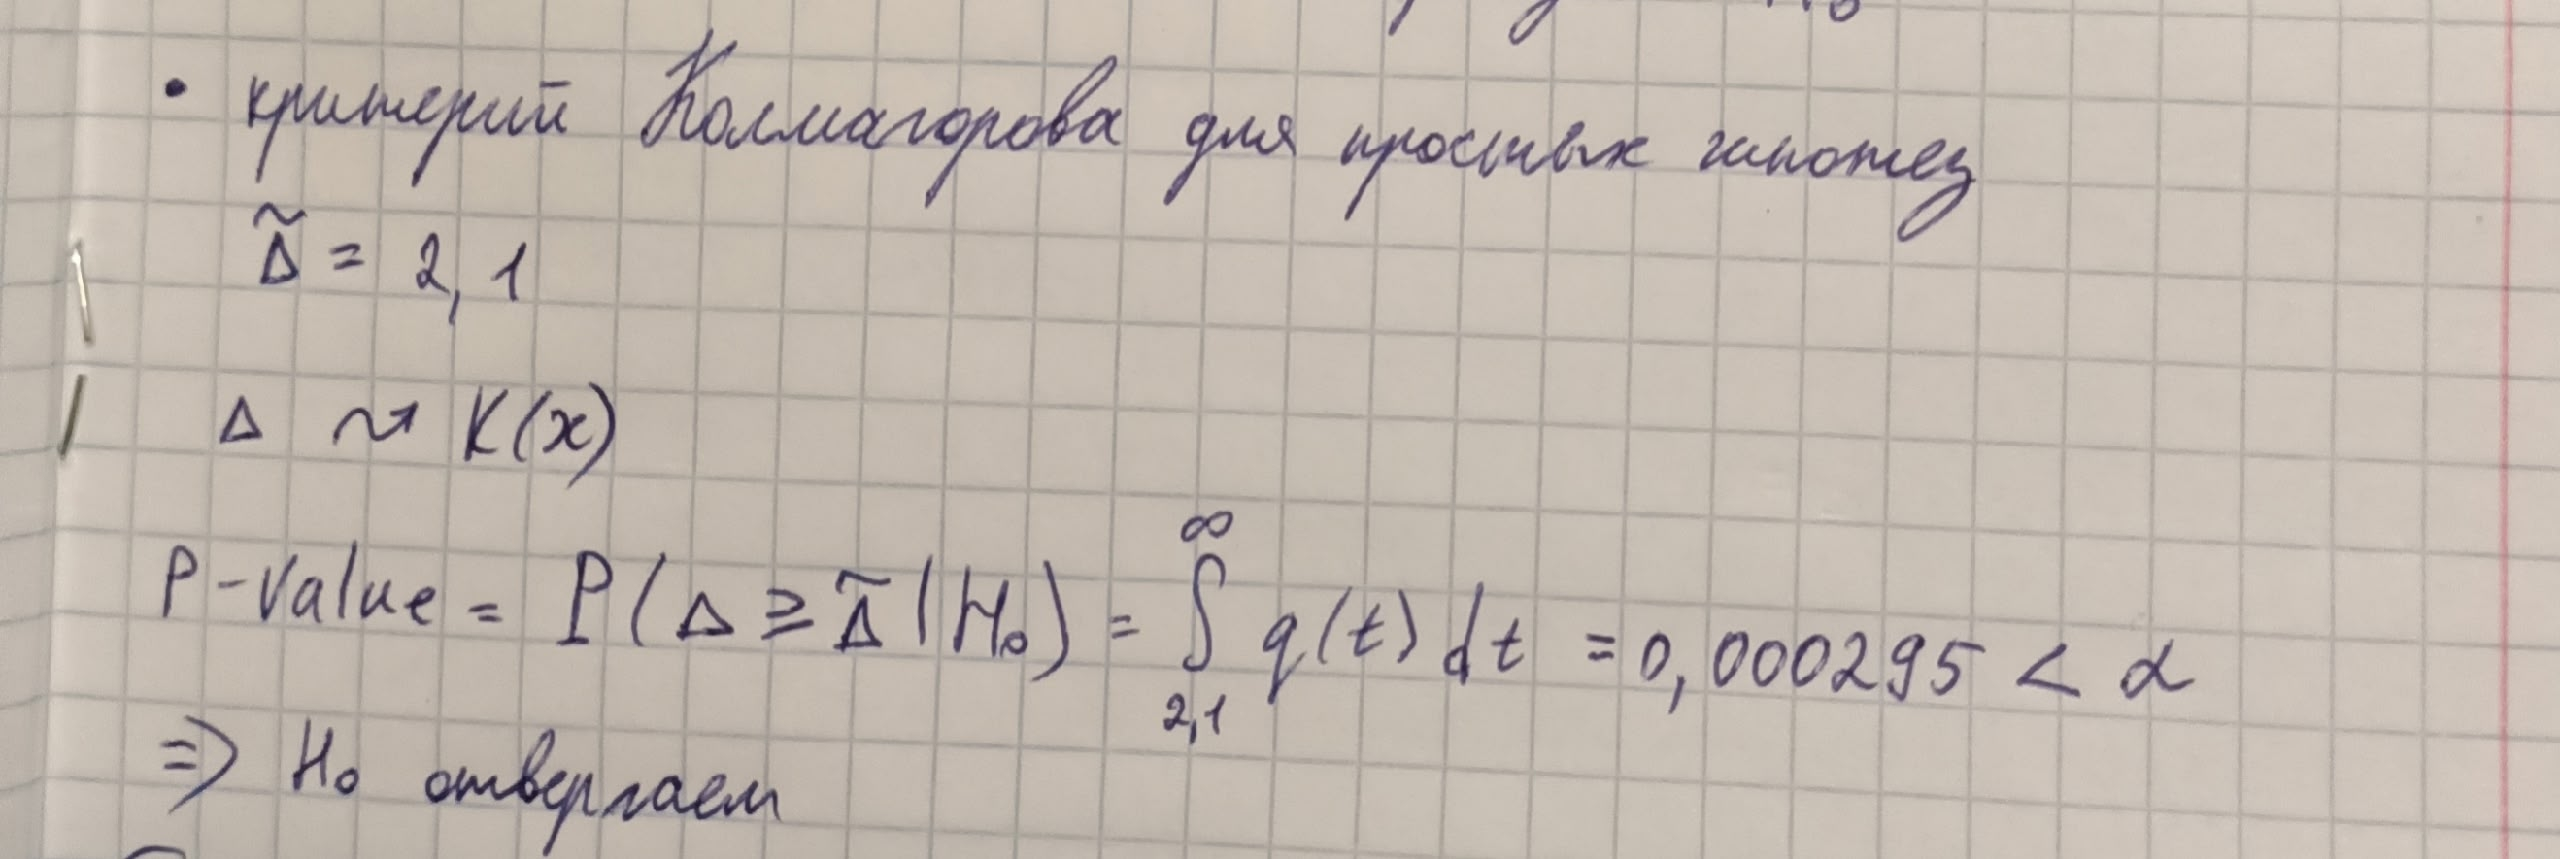

In [7]:
p_value = kstwobign.sf(wave_delta)
print(f"p-value = {p_value}")

p-value = 0.0002954967204631142


###Сравнение результатов
Критерий Колмагорова мощнее, чем критерий Пирсона, поэтому мы смогли отвергнуть $H_0$